# Customer Review Analysis

Objective:
Analyze customer reviews to understand overall sentiment and extract
business insights that support decision-making.
## Review Analysis (Sentiment + Complaints / Likes)

### This notebook:
1) Loads reviews dataset  
2) Computes sentiment using VADER (no training needed, computationally cheaper)  
3) Extracts top complaint keywords (negative reviews)  
4) Extracts top liked keywords (positive reviews)  
5) Saves outputs for dashboard/chatbot


In [105]:
import pandas as pd

DATA_PATH = r"..\..\data\raw\reviews_analysis\Amazon_Reviews.csv"
df = pd.read_csv(DATA_PATH, engine='python')

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


## Data Cleaning

In [106]:
df.isna().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [107]:
df.dropna(inplace=True)

In [108]:
df.isna().sum()

Reviewer Name         0
Profile Link          0
Country               0
Review Count          0
Review Date           0
Rating                0
Review Title          0
Review Text           0
Date of Experience    0
dtype: int64

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20946 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       20946 non-null  object
 1   Profile Link        20946 non-null  object
 2   Country             20946 non-null  object
 3   Review Count        20946 non-null  object
 4   Review Date         20946 non-null  object
 5   Rating              20946 non-null  object
 6   Review Title        20946 non-null  object
 7   Review Text         20946 non-null  object
 8   Date of Experience  20946 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [110]:
# Convert dates
df["Review Date"] = pd.to_datetime(df["Review Date"])

# Clean rating (extract number)
df["rating_num"] = df["Rating"].str.extract(r"(\d)").astype(int)

# Keep needed columns
df = df[["Review Date", "rating_num", "Review Text"]]

In [111]:

df.head(), 50*'-', df.describe(), 50*'-', df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20946 entries, 0 to 21213
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Review Date  20946 non-null  datetime64[ns, UTC]
 1   rating_num   20946 non-null  int32              
 2   Review Text  20946 non-null  object             
dtypes: datetime64[ns, UTC](1), int32(1), object(1)
memory usage: 572.7+ KB


(                Review Date  rating_num  \
 0 2024-09-16 13:44:26+00:00           1   
 1 2024-09-16 18:26:46+00:00           1   
 2 2024-09-16 21:47:39+00:00           1   
 3 2024-09-17 07:15:49+00:00           1   
 4 2024-09-16 18:37:17+00:00           1   
 
                                          Review Text  
 0  I registered on the website, tried to order a ...  
 1  Had multiple orders one turned up and driver h...  
 2  I informed these reprobates that I WOULD NOT B...  
 3  I have bought from Amazon before and no proble...  
 4  If I could give a lower rate I would! I cancel...  ,
 '--------------------------------------------------',
          rating_num
 count  20946.000000
 mean       2.174305
 std        1.671130
 min        1.000000
 25%        1.000000
 50%        1.000000
 75%        4.000000
 max        5.000000,
 '--------------------------------------------------',
 None)

### Since sentiment analysis is lexicon-based, class imbalance in ratings does not bias the results, making VADER suitable for this dataset.

<Axes: xlabel='rating_num'>

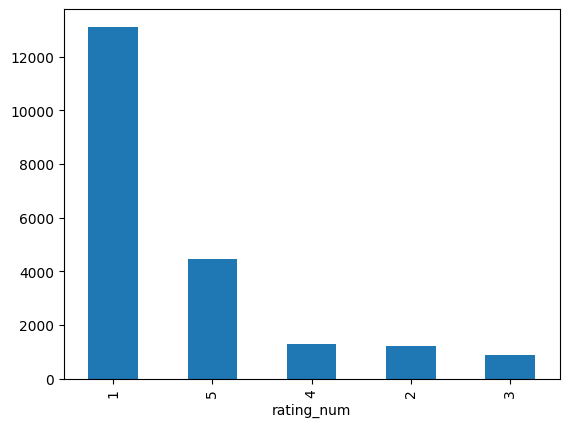

In [112]:
df['rating_num'].value_counts().plot(kind='bar')

In [113]:
from collections import Counter
import re
# import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# nltk.download("vader_lexicon")
# nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
sia = SentimentIntensityAnalyzer()

# df["sentiment_score"] = df["Review Text"].apply(
#     lambda x: sia.polarity_scores(str(x))["compound"]
# )

In [ ]:
def label_sentiment(score):
    if score >=3:
        return "positive"
    elif score <=2:
        return "negative"

def extract_keywords(texts, top_n=15):
    domain_stopwords = {
    "amazon", "customer", "service", "delivery", "order",
    "item", "account", "get", "time", "would", "dont", "prime"
    }
    ambiguous_words = {
    "one", "day", "back", "company", "items", "item", "never","found","best","love","good",
    "great","always","could","still","like","even"
    }
    unigrams = []
    bigrams = []

    for text in texts:
        text = str(text).lower()
        text = re.sub(r"[^a-z\s]", " ", text)

        tokens = [
            w for w in text.split()
            if w not in stop_words
            and w not in domain_stopwords
            and w not in ambiguous_words
            and len(w) > 2
        ]

        # single words
        unigrams.extend(tokens)

        # two-word phrases
        for i in range(len(tokens) - 1):
            bigrams.append(tokens[i] + " " + tokens[i + 1])

    # prioritize bigrams, fallback to unigrams
    combined = Counter(bigrams + unigrams)

    return combined.most_common(top_n)


In [130]:
df["sentiment"] = df["rating_num"].apply(label_sentiment)
df.head()

,Review Date,rating_num,Review Text,sentiment
0,2024-09-16 13:44:26+00:00,1,"I registered on the website, tried to order a ...",negative
1,2024-09-16 18:26:46+00:00,1,Had multiple orders one turned up and driver h...,negative
2,2024-09-16 21:47:39+00:00,1,I informed these reprobates that I WOULD NOT B...,negative
3,2024-09-17 07:15:49+00:00,1,I have bought from Amazon before and no proble...,negative
4,2024-09-16 18:37:17+00:00,1,If I could give a lower rate I would! I cancel...,negative


In [131]:
df[df['rating_num']==1]

,Review Date,rating_num,Review Text,sentiment
0,2024-09-16 13:44:26+00:00,1,"I registered on the website, tried to order a ...",negative
1,2024-09-16 18:26:46+00:00,1,Had multiple orders one turned up and driver h...,negative
2,2024-09-16 21:47:39+00:00,1,I informed these reprobates that I WOULD NOT B...,negative
3,2024-09-17 07:15:49+00:00,1,I have bought from Amazon before and no proble...,negative
4,2024-09-16 18:37:17+00:00,1,If I could give a lower rate I would! I cancel...,negative
...,...,...,...,...
21007,2011-10-24 09:01:00+00:00,1,when you become a seller on amazon and you sta...,negative
21033,2011-10-12 01:23:40+00:00,1,I don't like how they have navigation. It seem...,negative
21074,2011-09-19 20:42:49+00:00,1,i use this company on a regular basis and will...,negative
21123,2011-08-20 19:29:57+00:00,1,"Bought 5 items from amazon over 2 days, the de...",negative


In [132]:
df["sentiment"].value_counts(normalize=True)

sentiment
negative    0.684952
positive    0.315048
Name: proportion, dtype: float64

In [133]:
df.groupby("sentiment")["rating_num"].mean()

sentiment
negative    1.085523
positive    4.541446
Name: rating_num, dtype: float64

In [134]:
negative_words = extract_keywords(
    df[df["sentiment"] == "negative"]["Review Text"]
)

positive_words = extract_keywords(
    df[df["sentiment"] == "positive"]["Review Text"]
)

negative_words, positive_words

([('refund', 4645),
  ('money', 3822),
  ('delivered', 3501),
  ('days', 3343),
  ('told', 3292),
  ('said', 3078),
  ('ordered', 3063),
  ('card', 2844),
  ('got', 2568),
  ('return', 2420),
  ('received', 2382),
  ('package', 2316),
  ('product', 2281),
  ('email', 2265),
  ('call', 2194)],
 [('products', 844),
  ('shipping', 785),
  ('review', 681),
  ('fast', 636),
  ('prices', 625),
  ('shopping', 615),
  ('use', 600),
  ('find', 585),
  ('buy', 565),
  ('years', 564),
  ('experience', 562),
  ('easy', 561),
  ('product', 560),
  ('ordered', 539),
  ('everything', 527)])

In [137]:
daily_insights = pd.DataFrame(
    df.groupby(df["Review Date"].dt.date)
      .agg(
          avg_rating=("rating_num", "mean"),
          positive_ratio=("sentiment", lambda x: (x=="positive").mean()),
          negative_ratio=("sentiment", lambda x: (x=="negative").mean())
      )
      .reset_index()
)

daily_insights.columns = ["date", "avg_rating", "positive_ratio", "negative_ratio"]
daily_insights.head()

,date,avg_rating,positive_ratio,negative_ratio
0,2007-08-27,4.0,1.0,0.0
1,2008-04-28,5.0,1.0,0.0
2,2008-09-16,3.0,1.0,0.0
3,2008-12-31,5.0,1.0,0.0
4,2009-03-22,5.0,1.0,0.0


In [139]:
daily_insights.to_csv(r"D:..\..\data\outputs\review_insights.csv", index=False)

rows = []
for word, count in negative_words:
    rows.append({"sentiment":"negative","keyword":word,"count":count})
for word, count in positive_words:
    rows.append({"sentiment":"positive","keyword":word,"count":count})

keywords_df = pd.DataFrame(rows).sort_values(["sentiment","count"], ascending=[True, False])
keywords_df.to_csv(r"..\..\data\outputs\review_keywords.csv", index=False)

print("Saved: data/outputs/review_insights.csv")
print("Saved: data/outputs/review_keywords.csv")


Saved: data/outputs/review_insights.csv
Saved: data/outputs/review_keywords.csv
